# Telecom Customer Churn Analysis & Retention Strategy

## Understand the Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

In [3]:
# Load dataset
df = pd.read_csv("Telco_Customer_Churn_Dataset.csv")

In [4]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [5]:
print(f"No. of Rows: {df.shape[0]} \nNo. of Columns: {df.shape[1]}")

No. of Rows: 7043 
No. of Columns: 21


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
#check for null values
pd.isnull(df).sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
#check for duplicated values
df.duplicated().sum()

np.int64(0)

In [9]:
#check for duplicated values for customerID
df['customerID'].duplicated().sum()

np.int64(0)

In [10]:
df['PaymentMethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

## Data Cleaning

In [11]:
df.columns = df.columns.str.lower()
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [12]:
# change data type
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

In [13]:
# Fill missing TotalCharges with median
df['totalcharges']= df['totalcharges'].fillna(df['totalcharges'].median())

In [14]:
#Changing SeniorCitizen values from 0,1 to yes & no
def convert_value(value):
    if value == 1 :
        return "yes"
    else :
        return "no"

df['seniorcitizen']=df['seniorcitizen'].apply(convert_value)

In [15]:
df['paymentmethod'] = df['paymentmethod'].replace({
    'Bank transfer (automatic)': 'Bank transfer',
    'Credit card (automatic)': 'Credit card'
})

In [16]:
df.head(10)

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer,42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,no,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,no,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card,89.10,1949.40,No
7,6713-OKOMC,Female,no,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,no,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,no,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer,56.15,3487.95,No


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   seniorcitizen     7043 non-null   object 
 3   partner           7043 non-null   object 
 4   dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   object 
 7   multiplelines     7043 non-null   object 
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  contract          7043 non-null   object 
 16  paperlessbilling  7043 non-null   object 


## Exploratory Data Analysis (EDA)

In [18]:
df.describe()

,tenure,monthlycharges,totalcharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928
std,24.559481,30.090047,2265.270398
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [23]:
import os
os.makedirs("images", exist_ok=True)

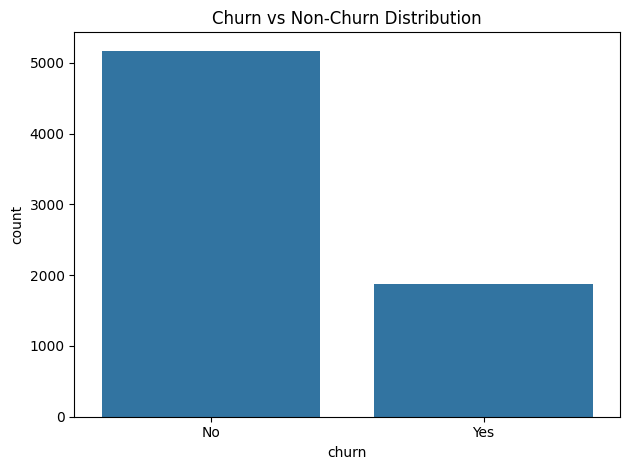

In [24]:
#Churn Distribution
sns.countplot(x='churn', data=df)
plt.title("Churn vs Non-Churn Distribution")
plt.tight_layout()
plt.savefig("images/01_Churn_vs_Non-Churn_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

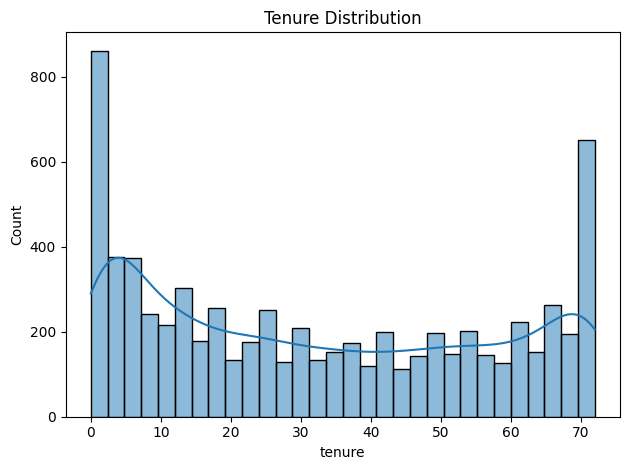

In [25]:
#Tenure Distribution
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title("Tenure Distribution")
plt.tight_layout()
plt.savefig("images/02_Tenure_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

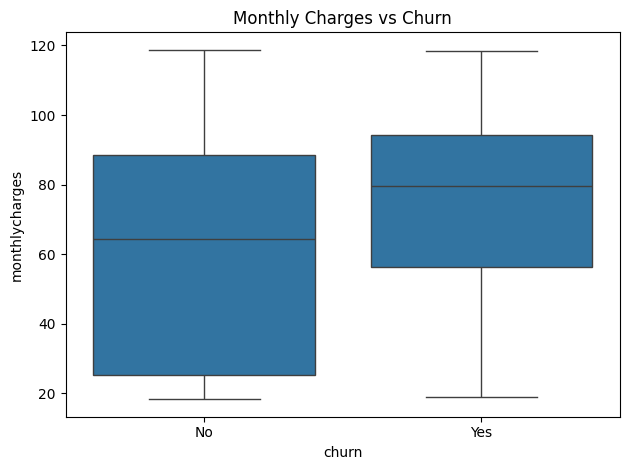

In [26]:
#Monthly Charges Boxplot
sns.boxplot(x='churn', y='monthlycharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.tight_layout()
plt.savefig("images/03_Monthly_Charges_vs_Churn.png", dpi=300, bbox_inches='tight')
plt.show()

## Customer Segmentation Visualization

In [27]:
#Create Tenure Categories
bins = [0, 12, 36, 72]
labels = ['0-12 Months', '13-36 Months', '37+ Months']

df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels)

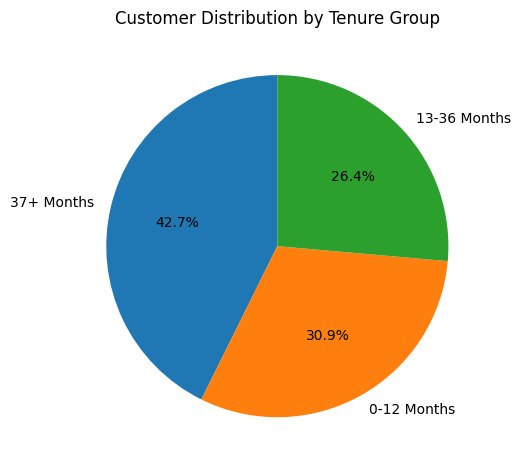

In [28]:
#Pie Chart (Tenure Distribution)
tenure_counts = df['tenure_group'].value_counts()

plt.pie(tenure_counts, labels=tenure_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Customer Distribution by Tenure Group")
plt.tight_layout()
plt.savefig("images/04_Customer_Distribution_by_Tenure_Group.png", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1586/827953539.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_charges = df.groupby('tenure_group')['monthlycharges'].mean()


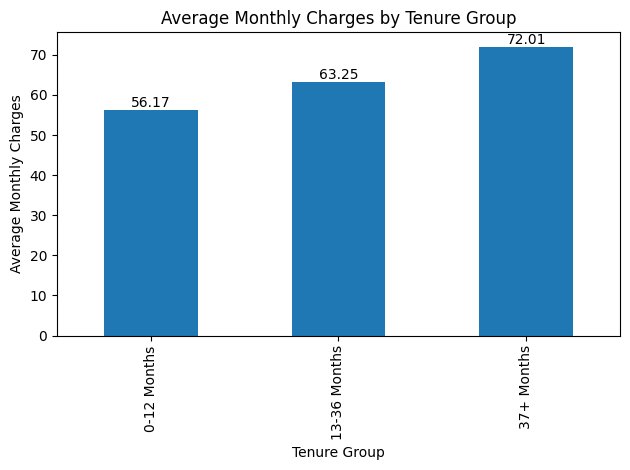

In [29]:
#Clustered Bar Chart (Monthly Charges)
avg_charges = df.groupby('tenure_group')['monthlycharges'].mean()

avg_charges.plot(kind='bar')
plt.title("Average Monthly Charges by Tenure Group")
plt.ylabel("Average Monthly Charges")
plt.xlabel("Tenure Group")

for index, value in enumerate(avg_charges):
    plt.text(index, value, round(value,2), ha='center', va='bottom')

plt.tight_layout()
plt.savefig("images/05_Average_Monthly_Charges_by_Tenure_Group.png", dpi=300, bbox_inches='tight')
plt.show()

## Advanced Analysis

/tmp/ipykernel_1586/3006988709.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_tenure = df.groupby('tenure_group')['churn'].value_counts(normalize=True).unstack()


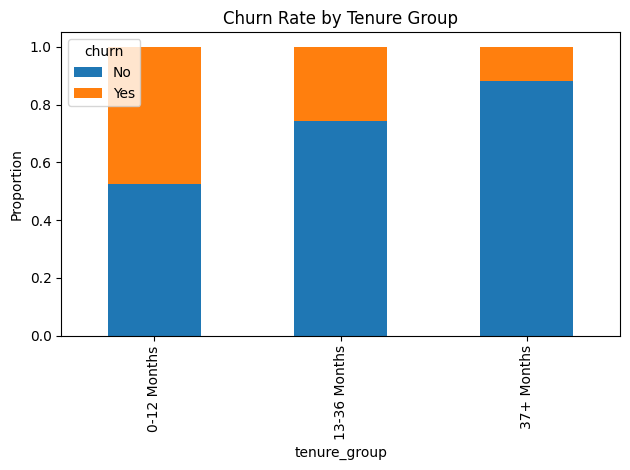

In [30]:
#Churn Rate by Tenure Group
churn_tenure = df.groupby('tenure_group')['churn'].value_counts(normalize=True).unstack()

churn_tenure.plot(kind='bar', stacked=True)
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Proportion")
plt.tight_layout()
plt.savefig("images/06_Churn_Rate_by_Tenure_Group.png", dpi=300, bbox_inches='tight')
plt.show()

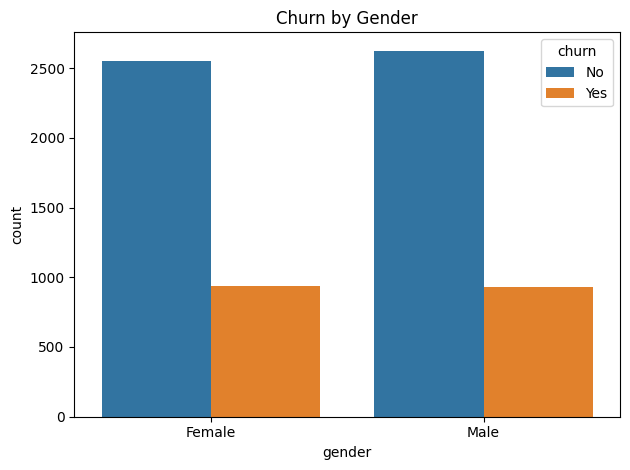

In [31]:
#Churn by Gender
sns.countplot(x='gender', hue='churn', data=df)
plt.title("Churn by Gender")
plt.tight_layout()
plt.savefig("images/07_Churn_by_Gender.png", dpi=300, bbox_inches='tight')
plt.show()

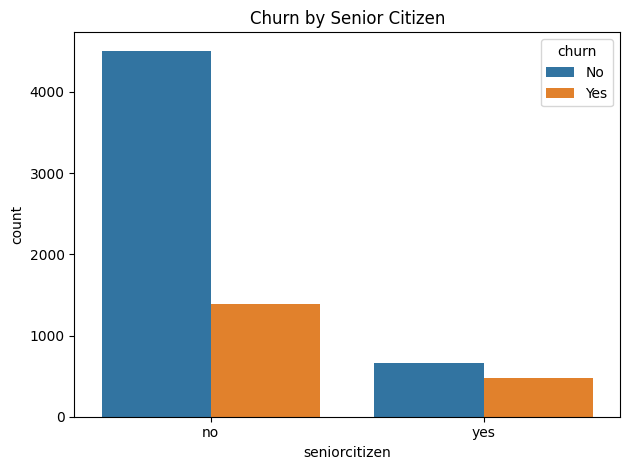

In [32]:
#Churn by Senior Citizen
sns.countplot(x='seniorcitizen', hue='churn', data=df)
plt.title("Churn by Senior Citizen")
plt.tight_layout()
plt.savefig("images/08_Churn by Senior Citizen.png", dpi=300, bbox_inches='tight')
plt.show()

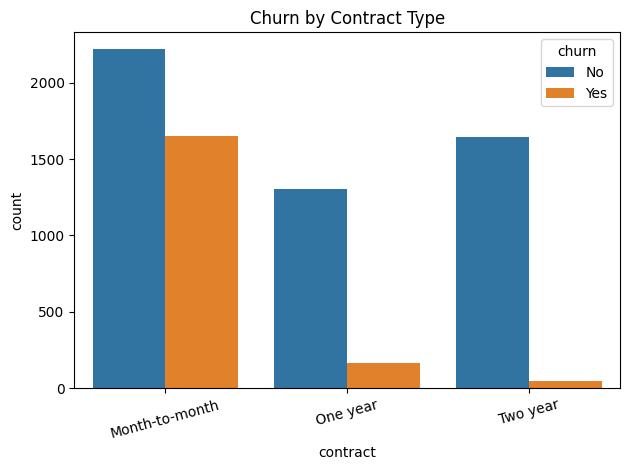

In [33]:
#Churn by Contract Type
sns.countplot(x='contract', hue='churn', data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("images/09_Churn_by_Contract_Type.png", dpi=300, bbox_inches='tight')
plt.show()

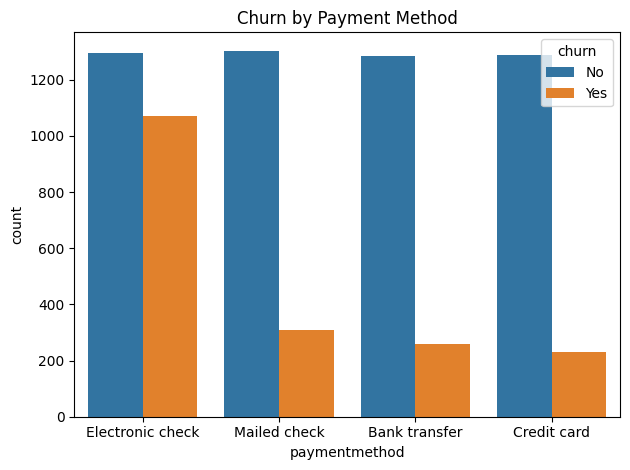

In [34]:
#Churn by Payment Method
sns.countplot(x='paymentmethod', hue='churn', data=df)
plt.title("Churn by Payment Method")
plt.tight_layout()
plt.savefig("images/10_Churn_by_Payment_Method.png", dpi=300, bbox_inches='tight')
plt.show()